# Notebook 2: Hồi quy Regularization

## Đọc dữ liệu

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import time
from sklearn.model_selection import KFold
# from sklearn.linear_model import Ridge

from utils import (
    load_bike_data,
    evaluate_model,
    plot_sklearn_learning_curve_wrapper,
    plot_learning_curve_data_size,
)

(
    train_df,
    features_to_drop,
    X_train_scaled,
    y_train,
    X_val_scaled,
    y_val,
    X_test_scaled,
    y_test,
    X_train_b,
    X_val_b,
    X_test_b,
) = load_bike_data()

X_train_scaled_b = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_val_scaled_b = np.c_[np.ones((X_val_scaled.shape[0], 1)), X_val_scaled]
X_test_scaled_b = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

## 2. Hồi quy Regularization

### 2.1 Ridge Regression (L2)

Optimal Lambda (Ridge): 0.7279


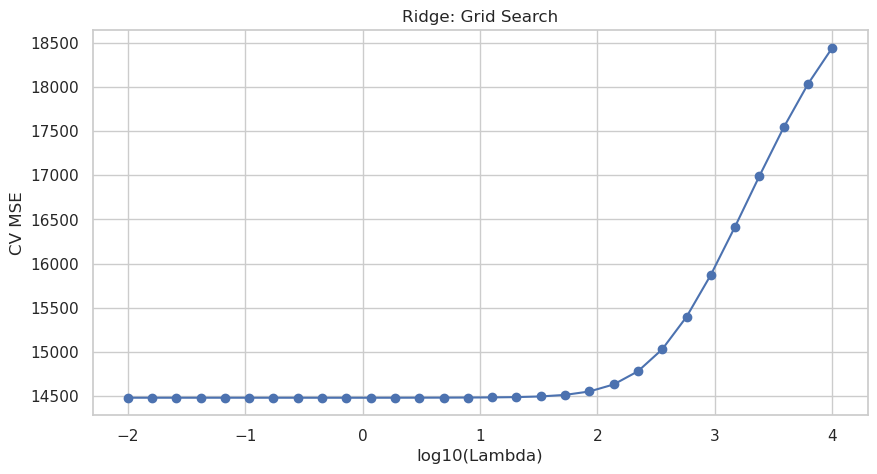

In [2]:
def ridge_closed_form(X, y, lam):
    n_features = X.shape[1]
    I = np.eye(n_features)
    I[0, 0] = 0  # Không regularize bias
    return np.linalg.pinv(X.T @ X + lam * I) @ X.T @ y


def ridge_cv(X, y, lambdas):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_errors = []

    for lam in lambdas:
        fold_errs = []
        for train_idx, val_idx in kf.split(X):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            w = ridge_closed_form(X_tr, y_tr, lam)
            y_pred = X_val @ w
            fold_errs.append(np.mean((y_val - y_pred) ** 2))

        cv_errors.append(np.mean(fold_errs))

    best_idx = np.argmin(cv_errors)
    return lambdas[best_idx], cv_errors


# Grid search
lambdas_ridge = np.logspace(-2, 4, 30)
best_lam_ridge, cv_errs_ridge = ridge_cv(X_train_scaled_b, y_train, lambdas_ridge)

print(f"Optimal Lambda (Ridge): {best_lam_ridge:.4f}")

# Plot CV curve
plt.figure(figsize=(10, 5))
plt.plot(np.log10(lambdas_ridge), cv_errs_ridge, marker="o")
plt.xlabel("log10(Lambda)")
plt.ylabel("CV MSE")
plt.title("Ridge: Grid Search")
plt.show()

#### Regularization Path (Ridge)

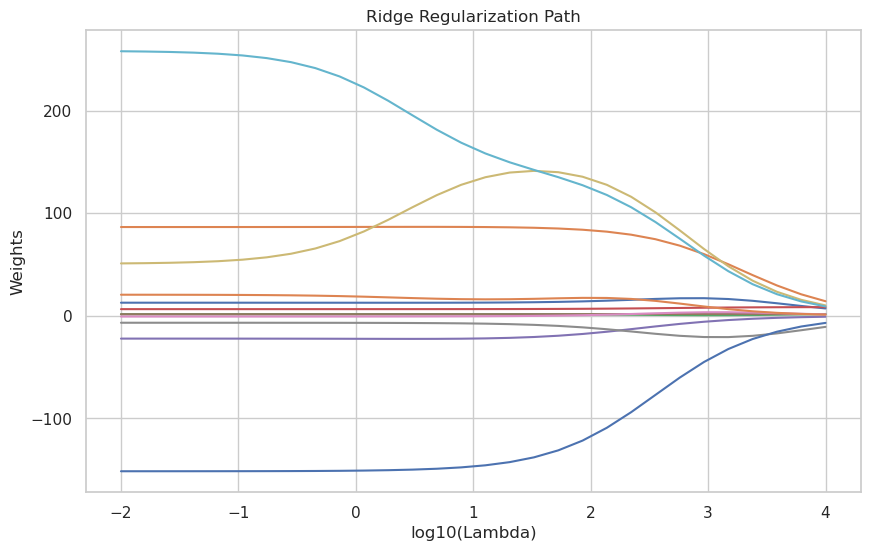

In [3]:
weights_ridge = []
for lam in lambdas_ridge:
    w = ridge_closed_form(X_train_scaled_b, y_train, lam)
    weights_ridge.append(w[1:])  # bỏ bias

weights_ridge = np.array(weights_ridge)

plt.figure(figsize=(10, 6))
for i in range(weights_ridge.shape[1]):
    plt.plot(np.log10(lambdas_ridge), weights_ridge[:, i])
plt.xlabel("log10(Lambda)")
plt.ylabel("Weights")
plt.title("Ridge Regularization Path")
plt.show()

[Ridge (L2)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17709.98 ± 9426.24
  - CV_RMSE (Mean ± Std): 128.48 ± 34.70
  - CV_MAE (Mean ± Std): 99.68 ± 29.58
  - CV_R2 (Mean ± Std): 0.1667 ± 0.2957
  - Val MSE: 33618.9606
  - Val RMSE: 183.3547
  - Val MAE: 148.9270
  - Val R2: 0.2984
  - Test MSE: 33596.3755
  - Test RMSE: 183.2931
  - Test MAE: 138.3253
  - Test R2: 0.3089


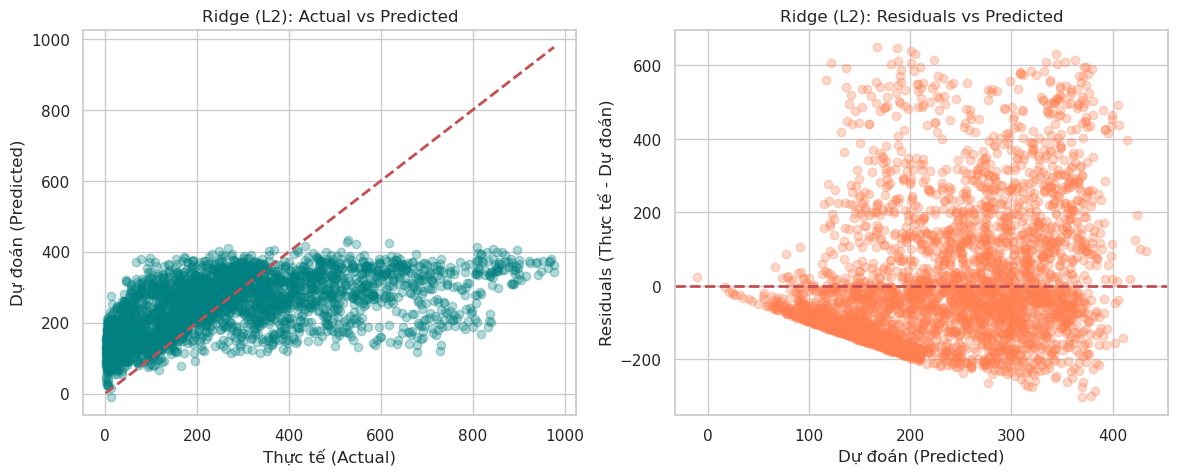

In [4]:
def fit_pred_ridge(X_tr, y_tr, X_val):
    w = ridge_closed_form(X_tr, y_tr, best_lam_ridge)
    return X_val @ w, w


_ = evaluate_model(
    "Ridge (L2)",
    fit_pred_ridge,
    X_train_scaled_b,
    y_train,
    X_test_scaled_b,
    y_test,
    X_val_scaled_b,
    y_val
)

### 2.2 Lasso Regression (L1 - Coordinate Descent)

Optimal Lambda (Lasso): 0.1000


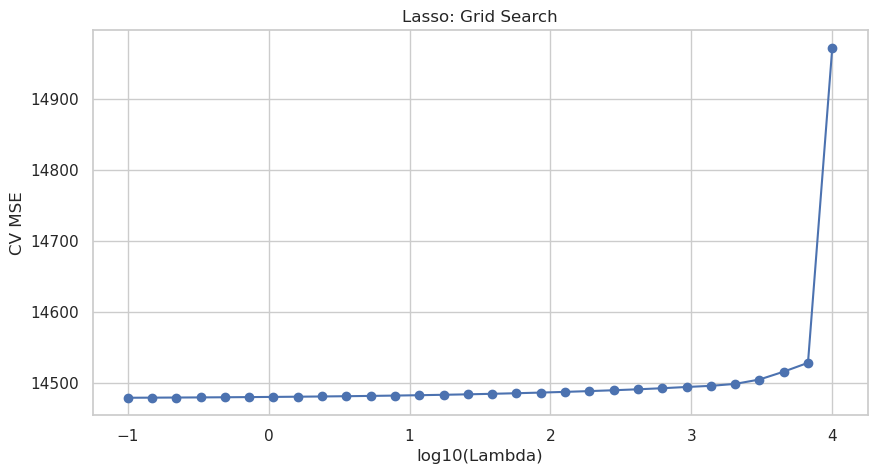

In [5]:
def soft_threshold(rho, lam):
    if rho < -lam:
        return rho + lam
    elif rho > lam:
        return rho - lam
    return 0.0


def lasso_cd(X, y, lam, epochs=30, w_init=None):
    m, n = X.shape
    w = np.zeros(n) if w_init is None else w_init.copy()
    losses = []

    for _ in range(epochs):
        for j in range(n):
            X_j = X[:, j]
            residual = y - (X @ w - w[j] * X_j)
            rho = X_j.T @ residual

            if j == 0:
                w[j] = rho / (X_j.T @ X_j)
            else:
                w[j] = soft_threshold(rho, lam) / (X_j.T @ X_j)

        loss = np.mean((X @ w - y) ** 2) + lam * np.sum(np.abs(w[1:])) / m
        losses.append(loss)

    return w, losses


def lasso_cv(X, y, lambdas, epochs=30):
    kf = KFold(n_splits=10, shuffle=True, random_state=42)
    cv_errors = []

    warm_starts = [np.zeros(X.shape[1]) for _ in range(10)]

    for lam in lambdas:
        fold_errs = []
        for i, (train_idx, val_idx) in enumerate(kf.split(X)):
            X_tr, X_val = X[train_idx], X[val_idx]
            y_tr, y_val = y[train_idx], y[val_idx]

            w, _ = lasso_cd(X_tr, y_tr, lam, epochs, warm_starts[i])
            warm_starts[i] = w

            y_pred = X_val @ w
            fold_errs.append(np.mean((y_val - y_pred) ** 2))

        cv_errors.append(np.mean(fold_errs))

    best_idx = np.argmin(cv_errors)
    return lambdas[best_idx], cv_errors


# Grid search
lambdas_lasso = np.logspace(4, -1, 30)
best_lam_lasso, cv_errs_lasso = lasso_cv(X_train_scaled_b, y_train, lambdas_lasso)

print(f"Optimal Lambda (Lasso): {best_lam_lasso:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(np.log10(lambdas_lasso), cv_errs_lasso, marker="o")
plt.xlabel("log10(Lambda)")
plt.ylabel("CV MSE")
plt.title("Lasso: Grid Search")
plt.show()

#### Regularization Path (Lasso)

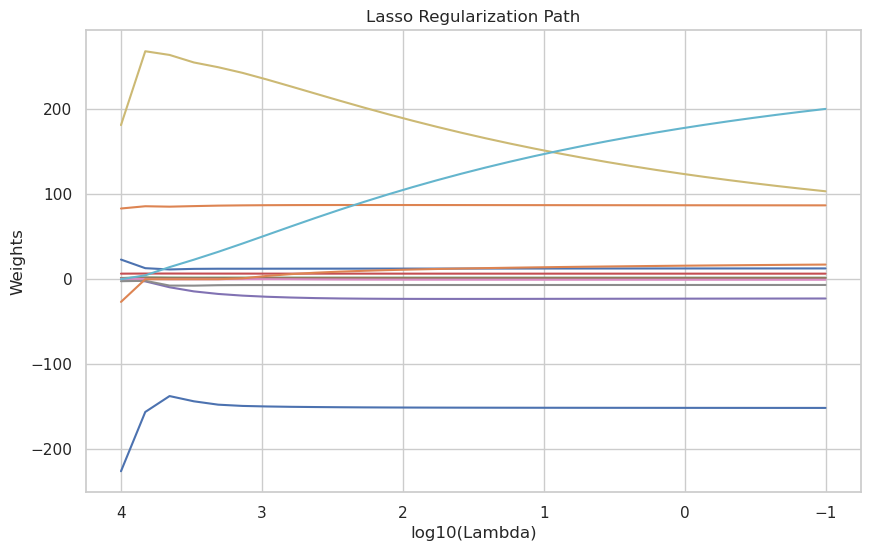

In [6]:
weights_lasso = []
w_warm = np.zeros(X_train_scaled_b.shape[1])

for lam in lambdas_lasso:
    w_warm, _ = lasso_cd(X_train_scaled_b, y_train, lam, epochs=30, w_init=w_warm)
    weights_lasso.append(w_warm[1:])

weights_lasso = np.array(weights_lasso)

plt.figure(figsize=(10, 6))
for i in range(weights_lasso.shape[1]):
    plt.plot(np.log10(lambdas_lasso), weights_lasso[:, i])

plt.gca().invert_xaxis()
plt.xlabel("log10(Lambda)")
plt.ylabel("Weights")
plt.title("Lasso Regularization Path")
plt.show()

[Lasso (L1)] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 18093.49 ± 9260.77
  - CV_RMSE (Mean ± Std): 130.26 ± 33.56
  - CV_MAE (Mean ± Std): 102.26 ± 28.54
  - CV_R2 (Mean ± Std): 0.1306 ± 0.3365
  - Val MSE: 33587.6706
  - Val RMSE: 183.2694
  - Val MAE: 150.1083
  - Val R2: 0.2990
  - Test MSE: 33193.8750
  - Test RMSE: 182.1919
  - Test MAE: 142.0144
  - Test R2: 0.3172


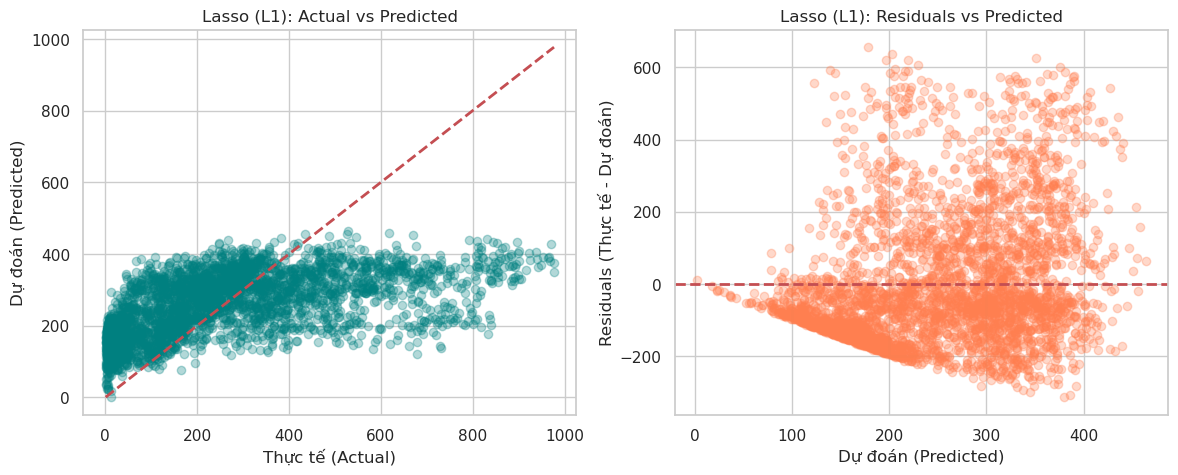

In [7]:
def fit_pred_lasso(X_tr, y_tr, X_val):
    w, _ = lasso_cd(X_tr, y_tr, best_lam_lasso, epochs=50)
    return X_val @ w, w


_ = evaluate_model(
    "Lasso (L1)",
    fit_pred_lasso,
    X_train_scaled_b,
    y_train,
    X_test_scaled_b,
    y_test,
    X_val_scaled_b,
    y_val
)

### 2.3 Elastic Net
Biểu đồ Learning Curves hội tụ bằng Coordinate Descent

Optimal Lam1 for Elastic Net: 0.00100
Optimal Lam2 for Elastic Net: 0.00774


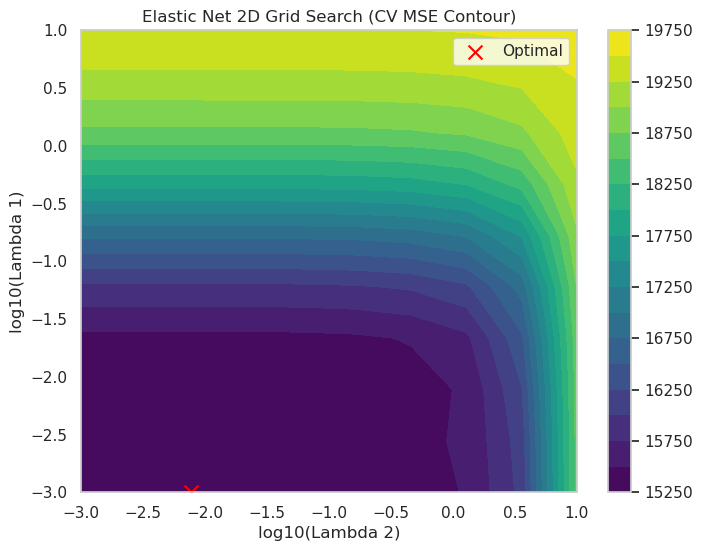

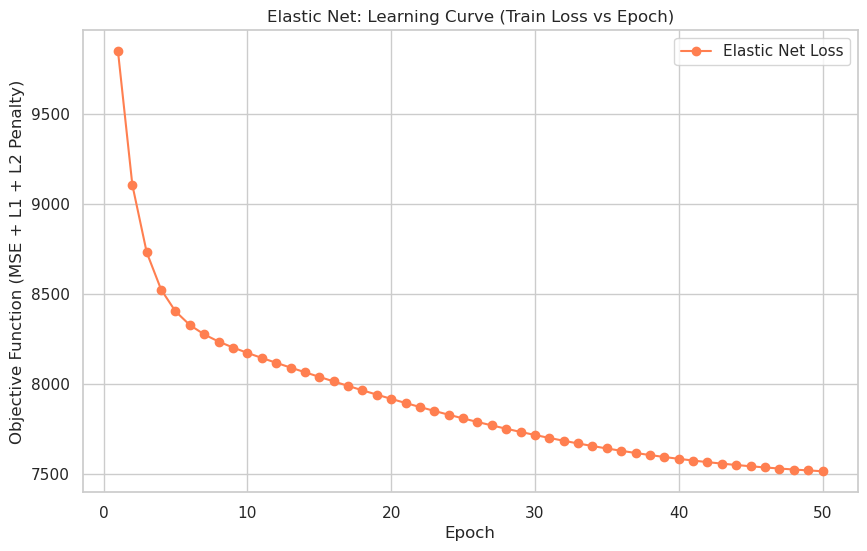

[Elastic Net] Kết quả đánh giá:
  - CV_MSE (Mean ± Std): 17737.57 ± 9402.52
  - CV_RMSE (Mean ± Std): 128.63 ± 34.52
  - CV_MAE (Mean ± Std): 100.73 ± 28.57
  - CV_R2 (Mean ± Std): 0.1640 ± 0.2963
  - Val MSE: 33678.8993
  - Val RMSE: 183.5181
  - Val MAE: 149.2270
  - Val R2: 0.2971
  - Test MSE: 33586.3446
  - Test RMSE: 183.2658
  - Test MAE: 141.9452
  - Test R2: 0.3091


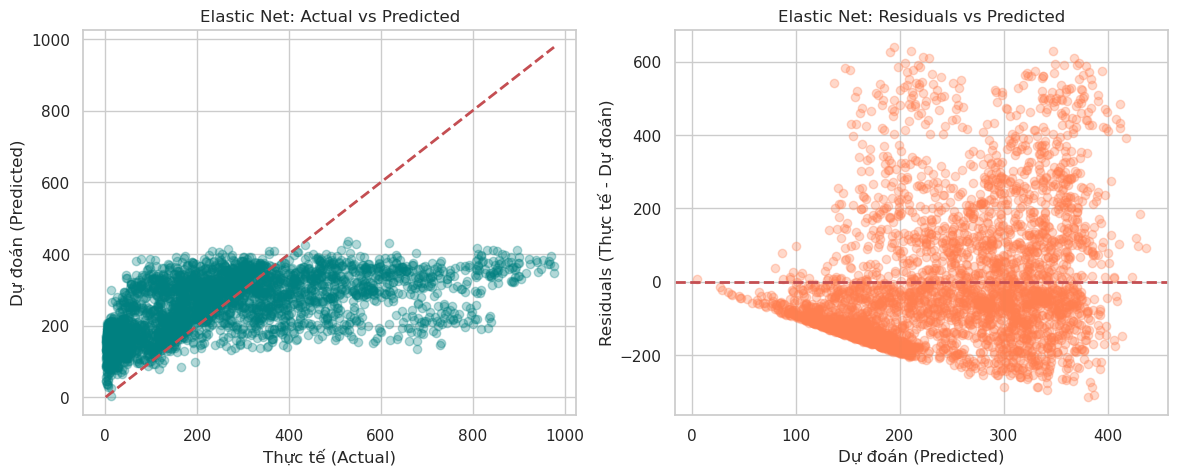

In [8]:
def elastic_net(X, y, lam1=1.0, lam2=1.0, epochs=30):
    m, n = X.shape
    w = np.zeros(n)
    losses = []

    for epoch in range(epochs):
        for j in range(n):
            X_j = X[:, j]
            y_pred_no_j = X.dot(w) - w[j] * X_j
            rho = X_j.T.dot(y - y_pred_no_j)

            if j == 0:
                w[j] = rho / (X_j.T.dot(X_j))
            else:
                w[j] = soft_threshold(rho, m * lam1) / (X_j.T.dot(X_j) + m * lam2)

        # Loss: 1/2m * MSE + l1*|w| + l2/2*w^2
        current_loss = (
            np.mean((X.dot(w) - y) ** 2) / 2.0
            + lam1 * np.sum(np.abs(w[1:]))
            + (lam2 / 2.0) * np.sum(w[1:] ** 2)
        )
        losses.append(current_loss)

    return w, losses


lam1_grid = np.logspace(-3, 1, 10)
lam2_grid = np.logspace(-3, 1, 10)
cv_errors_elastic = np.zeros((len(lam1_grid), len(lam2_grid)))

kf_el = KFold(n_splits=5, shuffle=True, random_state=42)
for i, l1 in enumerate(lam1_grid):
    for j, l2 in enumerate(lam2_grid):
        fold_errs = []
        for train_index, val_index in kf_el.split(X_train_scaled_b):
            X_fold_train, X_fold_val = (
                X_train_scaled_b[train_index],
                X_train_scaled_b[val_index],
            )
            y_fold_train, y_fold_val = y_train[train_index], y_train[val_index]

            w_opt, _ = elastic_net(
                X_fold_train, y_fold_train, lam1=l1, lam2=l2, epochs=20
            )
            y_pred = X_fold_val.dot(w_opt)
            fold_errs.append(np.mean((y_fold_val - y_pred) ** 2))
        cv_errors_elastic[i, j] = np.mean(fold_errs)

min_idx = np.unravel_index(np.argmin(cv_errors_elastic), cv_errors_elastic.shape)
best_lam1_el = lam1_grid[min_idx[0]]
best_lam2_el = lam2_grid[min_idx[1]]
print(f"Optimal Lam1 for Elastic Net: {best_lam1_el:.5f}")
print(f"Optimal Lam2 for Elastic Net: {best_lam2_el:.5f}")

L1, L2 = np.meshgrid(lam2_grid, lam1_grid)
plt.figure(figsize=(8, 6))
cp = plt.contourf(
    np.log10(L2), np.log10(L1), cv_errors_elastic, levels=20, cmap="viridis"
)
plt.colorbar(cp)
plt.scatter(
    np.log10(best_lam2_el),
    np.log10(best_lam1_el),
    color="red",
    marker="x",
    s=100,
    label="Optimal",
)
plt.xlabel("log10(Lambda 2)")
plt.ylabel("log10(Lambda 1)")
plt.title("Elastic Net 2D Grid Search (CV MSE Contour)")
plt.legend()
plt.show()

w_elastic, elastic_losses = elastic_net(
    X_train_scaled_b, y_train, lam1=best_lam1_el, lam2=best_lam2_el, epochs=50
)

plt.figure(figsize=(10, 6))
plt.plot(
    range(1, 51), elastic_losses, marker="o", color="coral", label="Elastic Net Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Objective Function (MSE + L1 + L2 Penalty)")
plt.title("Elastic Net: Learning Curve (Train Loss vs Epoch)")
plt.legend()
plt.show()


def fit_pred_elastic(X_tr, y_tr, X_val):
    w, _ = elastic_net(X_tr, y_tr, lam1=best_lam1_el, lam2=best_lam2_el, epochs=50)
    return X_val.dot(w), w


_ = evaluate_model(
    "Elastic Net",
    fit_pred_elastic,
    X_train_scaled_b,
    y_train,
    X_test_scaled_b,
    y_test,
    X_val_scaled_b,
    y_val,
)

### 2.4 Lựa chọn đặc trưng (Feature Selection)
1. Lasso Nonzero Coefficients: Các biến có hệ số w khác 0
2. Forward Stepwise Selection: Thêm từng biến làm giảm MSE validation nhiều nhất
3. Backward Elimination: Chặt dần từ full model biến ít ảnh hưởng nhất

In [9]:

feature_names = list(
    train_df.drop(columns=features_to_drop + ["cnt"], errors="ignore").columns
)

# 1. Lasso Nonzero
w_lasso, _ = lasso_cd(X_train_scaled_b, y_train, best_lam_lasso, epochs=50)
lasso_selected = []
for i, w_val in enumerate(w_lasso[1:]):
    if abs(w_val) > 1e-5:
        lasso_selected.append(feature_names[i])


# Helper measure MSE of a subset
def cv_err_subset(subset_indices):
    if len(subset_indices) == 0:
        return np.mean((y_train - np.mean(y_train)) ** 2)

    kf_sub = KFold(n_splits=5, shuffle=True, random_state=42)
    X_sub = X_train_scaled[:, subset_indices]
    X_sub_b = np.c_[np.ones((len(X_sub), 1)), X_sub]

    cv_errs = []
    for tr_idx, val_idx in kf_sub.split(X_sub_b):
        X_tr_f, X_val_f = X_sub_b[tr_idx], X_sub_b[val_idx]
        y_tr_f, y_val_f = y_train[tr_idx], y_train[val_idx]
        w_f = np.linalg.pinv(X_tr_f.T.dot(X_tr_f)).dot(X_tr_f.T).dot(y_tr_f)
        y_pred_f = X_val_f.dot(w_f)
        cv_errs.append(np.mean((y_val_f - y_pred_f) ** 2))
    return np.mean(cv_errs)


# 2. Forward Stepwise
forward_selected_indices = []
remaining_indices = list(range(len(feature_names)))
best_forward_mse = cv_err_subset([])

while remaining_indices:
    best_candidate = None
    best_candidate_mse = best_forward_mse

    for idx in remaining_indices:
        test_subset = forward_selected_indices + [idx]
        mse = cv_err_subset(test_subset)
        if mse < best_candidate_mse:
            best_candidate = idx
            best_candidate_mse = mse

    if best_candidate is not None:
        forward_selected_indices.append(best_candidate)
        remaining_indices.remove(best_candidate)
        best_forward_mse = best_candidate_mse
    else:
        break

forward_selected = [feature_names[i] for i in forward_selected_indices]

# 3. Backward Elimination
backward_selected_indices = list(range(len(feature_names)))
best_backward_mse = cv_err_subset(backward_selected_indices)

while len(backward_selected_indices) > 1:
    worst_candidate = None
    best_candidate_mse = best_backward_mse

    for idx in backward_selected_indices:
        test_subset = backward_selected_indices.copy()
        test_subset.remove(idx)
        mse = cv_err_subset(test_subset)
        if mse < best_candidate_mse:
            worst_candidate = idx
            best_candidate_mse = mse

    if worst_candidate is not None:
        backward_selected_indices.remove(worst_candidate)
        best_backward_mse = best_candidate_mse
    else:
        break

backward_selected = [feature_names[i] for i in backward_selected_indices]

print("\n" + "=" * 60)
print("=== TỔNG KẾT FEATURE SELECTION ===")
print("=" * 60)
print(f"Lasso Selected ({len(lasso_selected)} features): {lasso_selected}")
print(
    f"Forward Stepwise Selected ({len(forward_selected)} features): {forward_selected}"
)
print(
    f"Backward Elimination Selected ({len(backward_selected)} features): {backward_selected}"
)


=== TỔNG KẾT FEATURE SELECTION ===
Lasso Selected (12 features): ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']
Forward Stepwise Selected (11 features): ['temp', 'hr', 'yr', 'hum', 'season', 'atemp', 'holiday', 'weathersit', 'weekday', 'mnth', 'windspeed']
Backward Elimination Selected (10 features): ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'weathersit', 'atemp', 'hum', 'windspeed']
